In [2]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.neighbors import kneighbors_graph, NearestNeighbors
from scipy.sparse.csgraph import connected_components

import pickle
from joblib import Parallel, delayed

# Load and filter outlier cells

In [3]:
spatial = pd.read_csv(r'Y:\coskun-lab\Zhou\12_MSG\msg_germinal_centers\IF\20240808_multiplexed_IF\SSA+_83\00_analysis\83.csv', index_col=0)
spatial = spatial[spatial['area'] > 100]

In [4]:
spatial.drop(columns=['PDGFR'], inplace=True)

In [5]:
k = 5
adj_matrix = kneighbors_graph(spatial[['row', 'col']].values.astype('float'), n_neighbors=k, mode='distance', include_self=False)

In [6]:
n_components, labels = connected_components(adj_matrix, directed=False)

In [7]:
np.unique(labels, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7], dtype=int32),
 array([   10, 81571,     6,     8,     6,    15,    66,    13]))

In [8]:
# Initially, only keep the largest subgraph, unless there are other large subgraphs
valid_components = [0,1,2,3,4,5,6,7]
valid_nodes = np.isin(labels, valid_components)
adj_matrix = adj_matrix[valid_nodes][:, valid_nodes]
filtered_points = spatial.iloc[valid_nodes]

In [9]:
filtered_points.reset_index(drop=True, inplace=True)

In [10]:
filtered_points.shape

(81695, 17)

In [11]:
adj_matrix.shape

(81695, 81695)

In [123]:
# Remove the longest k edges
n_components, labels = connected_components(adj_matrix, directed=False)
prev_n_components = n_components
while n_components == prev_n_components:
    distances = adj_matrix.data
    row, col = adj_matrix.nonzero()
    k_remove = 1
    longest_edge_indices = np.argsort(distances)[-k_remove:]

    for idx in longest_edge_indices:
        adj_matrix[row[idx], col[idx]] = 0
        adj_matrix[col[idx], row[idx]] = 0
    adj_matrix.eliminate_zeros()
    n_components, labels = connected_components(adj_matrix, directed=False)

In [124]:
np.unique(labels, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6], dtype=int32),
 array([   10, 81532,     1,     6,    15,    66,    13]))

In [125]:
# Long edges and associated small subgraphs are removed here
valid_components = [0,1,4,5,6]
valid_nodes = np.isin(labels, valid_components)
adj_matrix = adj_matrix[valid_nodes][:, valid_nodes]
filtered_points = filtered_points.iloc[valid_nodes]
filtered_points.reset_index(drop=True, inplace=True)

In [126]:
filtered_points.shape

(81636, 17)

(np.float64(-248.68050803186657),
 np.float64(30806.052455269688),
 np.float64(3108.589760157751),
 np.float64(30401.81764160764))

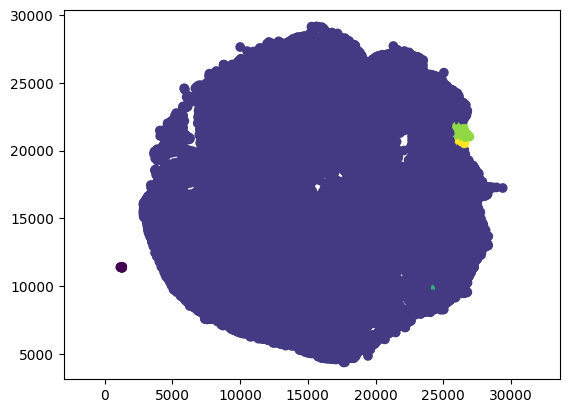

In [127]:
# visually inspect the graph
plt.scatter(filtered_points['row'], filtered_points['col'], c=labels[valid_nodes])
plt.axis('equal')

In [ ]:
filtered_points.to_csv(r'..\..\results\gat\83_spatial_filtered.csv', index=False, mode='w', line_terminator='\n')

OSError: [Errno 28] No space left on device: '..\\..\\results\\gat\\83_spatial_filtered.csv'

In [191]:
row,col = adj_matrix.nonzero()
edges = np.column_stack((row,col))
unique_edges = edges[edges[:, 0] < edges[:, 1]]

In [192]:
with open(r'..\..\results\gat\83_filtered_edges.pkl', 'wb') as f:
    pickle.dump(unique_edges, f)

# per tissue processing

In [2]:
from collections import defaultdict, deque

def build_adjacency_list(edges, num_nodes):
    adj = defaultdict(set)
    for u, v in edges:
        adj[u].add(v)
        adj[v].add(u)
    return adj

def k_hop_neighbors(cell, cell_metadata, edges, k):
    idx = cell_metadata.index.get_loc(cell)
    num_nodes = len(cell_metadata)
    adj = build_adjacency_list(edges, num_nodes)

    visited = set([idx])
    queue = deque([(idx, 0)])
    
    while queue:
        current, depth = queue.popleft()
        if depth >= k:
            continue
        for neighbor in adj[current]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append((neighbor, depth + 1))

    return list(visited)

def edges_in_subgraph(neighborhood, edges):
    neighborhood = set(neighborhood)
    subgraph_edges = []
    for edge in edges:
        if edge[0] in neighborhood and edge[1] in neighborhood:
            subgraph_edges.append(edge)
    return subgraph_edges

In [3]:
# Processing function
def sub_graphs(cell, cell_metadata, edges):
    two_hop = k_hop_neighbors(cell, cell_metadata, edges, 2)

    two_hop_edges = edges_in_subgraph(two_hop, edges)
    two_hop_edges_by_id = []
    for item in two_hop_edges:
        two_hop_edges_by_id.append((cell_metadata.iloc[item[0]]['label'], cell_metadata.iloc[item[1]]['label']))

    return two_hop_edges_by_id

## 126-1

In [4]:
if_df = pd.read_csv(r'..\..\results\gat\126-1_spatial_filtered.csv')
edges = pd.read_pickle(r'..\..\results\gat\126-1_filtered_edges.pkl')
pockets = pd.read_csv(r'..\..\results\gat\stromal_pockets\126-1_stromal.csv')

In [68]:
knn = NearestNeighbors(n_neighbors=1)
knn.fit(if_df[['row', 'col']].values.astype('float'))
distance, neighbors = knn.kneighbors(pockets[['row', 'col']].values.astype('float'))

In [69]:
sub_graphs_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, if_df, edges) for cell in neighbors.flatten())

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 22 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.02651810646057129s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]

In [70]:
with open(r'..\..\results\gat\sub_graphs_1261.pkl', 'wb') as f:
    pickle.dump(sub_graphs_l, f)

In [71]:
with open(r'..\..\results\gat\sub_graphs_1261_cell_index.pkl', 'wb') as f:
    pickle.dump(neighbors, f)

## 126-2

In [72]:
if_df = pd.read_csv(r'..\..\results\gat\126-2_spatial_filtered.csv')
edges = pd.read_pickle(r'..\..\results\gat\126-2_filtered_edges.pkl')
pockets = pd.read_csv(r'..\..\results\gat\stromal_pockets\126-2_stromal.csv')

In [73]:
knn = NearestNeighbors(n_neighbors=1)
knn.fit(if_df[['row', 'col']].values.astype('float'))
distance, neighbors = knn.kneighbors(pockets[['row', 'col']].values.astype('float'))

In [74]:
sub_graphs_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, if_df, edges) for cell in neighbors.flatten())

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 22 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.01763439178466797s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]

In [75]:
with open(r'..\..\results\gat\sub_graphs_1262.pkl', 'wb') as f:
    pickle.dump(sub_graphs_l, f)

In [76]:
with open(r'..\..\results\gat\sub_graphs_1262_cell_index.pkl', 'wb') as f:
    pickle.dump(neighbors, f)

## 7223-1

In [77]:
if_df = pd.read_csv(r'..\..\results\gat\7223-1_spatial_filtered.csv')
edges = pd.read_pickle(r'..\..\results\gat\7223-1_filtered_edges.pkl')
pockets = pd.read_csv(r'..\..\results\gat\stromal_pockets\7223-1_stromal.csv')

In [78]:
knn = NearestNeighbors(n_neighbors=1)
knn.fit(if_df[['row', 'col']].values.astype('float'))
distance, neighbors = knn.kneighbors(pockets[['row', 'col']].values.astype('float'))

In [79]:
sub_graphs_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, if_df, edges) for cell in neighbors.flatten())

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 22 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.055052995681762695s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)

In [80]:
with open(r'..\..\results\gat\sub_graphs_72231.pkl', 'wb') as f:
    pickle.dump(sub_graphs_l, f)

In [81]:
with open(r'..\..\results\gat\sub_graphs_72231_cell_index.pkl', 'wb') as f:
    pickle.dump(neighbors, f)

## 7223-2

In [82]:
if_df = pd.read_csv(r'..\..\results\gat\7223-2_spatial_filtered.csv')
edges = pd.read_pickle(r'..\..\results\gat\7223-2_filtered_edges.pkl')
pockets = pd.read_csv(r'..\..\results\gat\stromal_pockets\7223-2_stromal.csv')

In [83]:
knn = NearestNeighbors(n_neighbors=1)
knn.fit(if_df[['row', 'col']].values.astype('float'))
distance, neighbors = knn.kneighbors(pockets[['row', 'col']].values.astype('float'))

In [84]:
sub_graphs_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, if_df, edges) for cell in neighbors.flatten())

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 22 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.04411792755126953s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]

In [85]:
with open(r'..\..\results\gat\sub_graphs_72232.pkl', 'wb') as f:
    pickle.dump(sub_graphs_l, f)

In [86]:
with open(r'..\..\results\gat\sub_graphs_72232_cell_index.pkl', 'wb') as f:
    pickle.dump(neighbors, f)

## 83

In [193]:
if_df = pd.read_csv(r'..\..\results\gat\83_spatial_filtered.csv')
edges = pd.read_pickle(r'..\..\results\gat\83_filtered_edges.pkl')
pockets = pd.read_csv(r'..\..\results\gat\stromal_pockets\83_stromal.csv')

In [194]:
knn = NearestNeighbors(n_neighbors=1)
knn.fit(if_df[['row', 'col']].values.astype('float'))
distance, neighbors = knn.kneighbors(pockets[['row', 'col']].values.astype('float'))

In [195]:
sub_graphs_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, if_df, edges) for cell in neighbors.flatten())

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 22 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    3.2s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    3.3s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    3.6s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    3.9s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    3.9s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    4.2s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    4.3s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    4.3s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    4.4s
[Parallel(n_jobs=-3)]: Done  14 tasks      | elapsed:    4.7s
[Parallel(n_jobs=-3)]: Done  15 tasks      | elapsed:  

In [196]:
with open(r'..\..\results\gat\sub_graphs_83.pkl', 'wb') as f:
    pickle.dump(sub_graphs_l, f)

In [197]:
with open(r'..\..\results\gat\sub_graphs_83_cell_index.pkl', 'wb') as f:
    pickle.dump(neighbors, f)

## 134

In [198]:
if_df = pd.read_csv(r'..\..\results\gat\134_spatial_filtered.csv')
edges = pd.read_pickle(r'..\..\results\gat\134_filtered_edges.pkl')
pockets = pd.read_csv(r'..\..\results\gat\stromal_pockets\134_stromal.csv')

In [199]:
knn = NearestNeighbors(n_neighbors=1)
knn.fit(if_df[['row', 'col']].values.astype('float'))
distance, neighbors = knn.kneighbors(pockets[['row', 'col']].values.astype('float'))

In [200]:
sub_graphs_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, if_df, edges) for cell in neighbors.flatten())

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 22 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.14519810676574707s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]

In [201]:
with open(r'..\..\results\gat\sub_graphs_134.pkl', 'wb') as f:
    pickle.dump(sub_graphs_l, f)

In [202]:
with open(r'..\..\results\gat\sub_graphs_134_cell_index.pkl', 'wb') as f:
    pickle.dump(neighbors, f)

## 141

In [203]:
if_df = pd.read_csv(r'..\..\results\gat\141_spatial_filtered.csv')
edges = pd.read_pickle(r'..\..\results\gat\141_filtered_edges.pkl')
pockets = pd.read_csv(r'..\..\results\gat\stromal_pockets\141_stromal.csv')

In [204]:
knn = NearestNeighbors(n_neighbors=1)
knn.fit(if_df[['row', 'col']].values.astype('float'))
distance, neighbors = knn.kneighbors(pockets[['row', 'col']].values.astype('float'))

In [205]:
sub_graphs_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, if_df, edges) for cell in neighbors.flatten())

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 22 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.07643532752990723s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]

In [206]:
with open(r'..\..\results\gat\sub_graphs_141.pkl', 'wb') as f:
    pickle.dump(sub_graphs_l, f)

In [207]:
with open(r'..\..\results\gat\sub_graphs_141_cell_index.pkl', 'wb') as f:
    pickle.dump(neighbors, f)